# Crime_Complaints_And_Arrests_NYC_Data_Project

### 1. 2025 Crime Complaints by NYC NTA
### 2. Crime Complaints by Day of Week
### 3. Monthly Crime Complaints by Victim Race
### 4. Hourly Crime Complaints: Season



In [68]:
import pandas as pd 
import seaborn as sns
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import random



In [ ]:
complaints_2025 = pd.read_csv("complaints_2025.csv")
complaints_2025

,cmplnt_num,cmplnt_fr_dt,cmplnt_fr_tm,cmplnt_to_dt,cmplnt_to_tm,addr_pct_cd,rpt_dt,ky_cd,ofns_desc,pd_cd,...,susp_sex,transit_district,latitude,longitude,lat_lon,patrol_boro,station_name,vic_age_group,vic_race,vic_sex
0,318196597,2025-12-31T00:00:00.000,11:57:00,2025-12-31T00:00:00.000,12:05:00,40,2025-12-31T00:00:00.000,109,GRAND LARCENY,443.0,...,U,NaN,40.817356,-73.909331,"(40.817356, -73.909331)",PATROL BORO BRONX,(null),25-44,AMERICAN INDIAN/ALASKAN NATIVE,M
1,318202640,2025-12-31T00:00:00.000,17:10:00,2025-12-31T00:00:00.000,17:18:00,14,2025-12-31T00:00:00.000,118,DANGEROUS WEAPONS,793.0,...,F,NaN,40.754177,-73.984595,"(40.75417678, -73.98459514)",PATROL BORO MAN SOUTH,(null),UNKNOWN,UNKNOWN,E
2,318170925,2025-12-30T00:00:00.000,23:40:00,2025-12-31T00:00:00.000,00:27:00,101,2025-12-31T00:00:00.000,344,ASSAULT 3 & RELATED OFFENSES,113.0,...,M,NaN,40.599187,-73.750221,"(40.599187, -73.750221)",PATROL BORO QUEENS SOUTH,(null),18-24,BLACK,M
3,318205041,2025-12-23T00:00:00.000,17:56:00,2025-12-23T00:00:00.000,18:04:00,108,2025-12-31T00:00:00.000,341,PETIT LARCENY,321.0,...,M,NaN,40.746705,-73.943472,"(40.746705, -73.943472)",PATROL BORO QUEENS NORTH,(null),UNKNOWN,UNKNOWN,D
4,318204044,2025-12-31T00:00:00.000,19:39:00,2025-12-31T00:00:00.000,19:39:00,103,2025-12-31T00:00:00.000,351,CRIMINAL MISCHIEF & RELATED OF,258.0,...,(null),NaN,40.708380,-73.791676,"(40.70837971, -73.79167576)",PATROL BORO QUEENS SOUTH,(null),UNKNOWN,UNKNOWN,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579556,298733274,2024-12-30T00:00:00.000,09:30:00,2024-12-31T00:00:00.000,14:30:00,48,2025-01-01T00:00:00.000,110,GRAND LARCENY OF MOTOR VEHICLE,441.0,...,(null),NaN,40.838593,-73.876457,"(40.838593, -73.876457)",PATROL BORO BRONX,(null),45-64,BLACK,F
579557,298749236,2025-01-01T00:00:00.000,00:50:00,2025-01-01T00:00:00.000,00:52:00,46,2025-01-01T00:00:00.000,113,FORGERY,725.0,...,M,NaN,40.847816,-73.907531,"(40.847815514765855, -73.90753109698773)",PATROL BORO BRONX,(null),UNKNOWN,UNKNOWN,M
579558,298712914,2025-01-01T00:00:00.000,03:10:00,2025-01-01T00:00:00.000,03:15:00,33,2025-01-01T00:00:00.000,110,GRAND LARCENY OF MOTOR VEHICLE,441.0,...,M,NaN,40.839531,-73.940889,"(40.839531, -73.940889)",PATROL BORO MAN NORTH,(null),45-64,AMERICAN INDIAN/ALASKAN NATIVE,M
579559,298712937,2025-01-01T00:00:00.000,01:22:00,2025-01-01T00:00:00.000,01:25:00,44,2025-01-01T00:00:00.000,118,DANGEROUS WEAPONS,792.0,...,M,NaN,40.844588,-73.904847,"(40.84458830022735, -73.90484654915383)",PATROL BORO BRONX,(null),UNKNOWN,UNKNOWN,E


In [48]:
arrest_2025 = pd.read_csv("arrests_2025.csv")
arrest_2025

,arrest_key,arrest_date,pd_cd,pd_desc,ky_cd,ofns_desc,law_code,law_cat_cd,arrest_boro,arrest_precinct,jurisdiction_code,age_group,perp_sex,perp_race,x_coord_cd,y_coord_cd,latitude,longitude,lon_lat
0,318204904,2025-12-31T00:00:00.000,782,"WEAPONS, POSSESSION, ETC",236.0,DANGEROUS WEAPONS,PL 2650101,M,K,81,0,45-64,M,BLACK,1003127,187889,40.682369,-73.931939,POINT (-73.93193899 40.6823685)
1,318192907,2025-12-31T00:00:00.000,109,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200501,F,M,14,0,(null),(null),WHITE HISPANIC,985802,213780,40.753463,-73.994399,POINT (-73.994399 40.753463)
2,318209021,2025-12-31T00:00:00.000,779,"PUBLIC ADMINISTRATION,UNCLASSI",126.0,MISCELLANEOUS PENAL LAW,PL 215510B,F,Q,109,0,25-44,M,BLACK HISPANIC,1040185,217007,40.762143,-73.798083,POINT (-73.798083 40.762143)
3,318198593,2025-12-31T00:00:00.000,113,"MENACING,UNCLASSIFIED",344.0,ASSAULT 3 & RELATED OFFENSES,PL 1201401,M,Q,104,0,45-64,M,WHITE,1011377,197016,40.707408,-73.902155,POINT (-73.902155 40.707408)
4,318202619,2025-12-31T00:00:00.000,782,"WEAPONS, POSSESSION, ETC",236.0,DANGEROUS WEAPONS,PL 2650102,M,M,14,0,25-44,M,BLACK,986568,214237,40.754707,-73.991633,POINT (-73.99163337 40.75470724)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278948,298746555,2025-01-01T00:00:00.000,101,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,B,41,0,(null),(null),BLACK,1011695,237702,40.819081,-73.900845,POINT (-73.900845 40.819081)
278949,298714540,2025-01-01T00:00:00.000,101,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,K,66,0,18-24,M,WHITE HISPANIC,984348,168623,40.629519,-73.999648,POINT (-73.999648 40.629519)
278950,298710709,2025-01-01T00:00:00.000,922,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348.0,VEHICLE AND TRAFFIC LAWS,VTL05110MU,M,B,44,0,(null),(null),BLACK,1009324,247086,40.844833,-73.909375,POINT (-73.90937492396961 40.84483348116061)
278951,298748907,2025-01-01T00:00:00.000,922,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348.0,VEHICLE AND TRAFFIC LAWS,VTL0511001,M,K,81,2,(null),(null),BLACK,1001545,187376,40.680964,-73.937644,POINT (-73.93764421223999 40.6809636649715)


In [ ]:
arrest_2025.dtypes

arrest_key             int64
arrest_date              str
pd_cd                  int64
pd_desc                  str
ky_cd                float64
ofns_desc                str
law_code                 str
law_cat_cd               str
arrest_boro              str
arrest_precinct        int64
jurisdiction_code      int64
age_group                str
perp_sex                 str
perp_race                str
x_coord_cd             int64
y_coord_cd             int64
latitude             float64
longitude            float64
lon_lat                  str
dtype: object

In [4]:
complaints_2025.columns

Index(['cmplnt_num', 'cmplnt_fr_dt', 'cmplnt_fr_tm', 'cmplnt_to_dt',
       'cmplnt_to_tm', 'addr_pct_cd', 'rpt_dt', 'ky_cd', 'ofns_desc', 'pd_cd',
       'pd_desc', 'crm_atpt_cptd_cd', 'law_cat_cd', 'boro_nm',
       'loc_of_occur_desc', 'prem_typ_desc', 'juris_desc', 'jurisdiction_code',
       'parks_nm', 'hadevelopt', 'housing_psa', 'x_coord_cd', 'y_coord_cd',
       'susp_age_group', 'susp_race', 'susp_sex', 'transit_district',
       'latitude', 'longitude', 'lat_lon', 'patrol_boro', 'station_name',
       'vic_age_group', 'vic_race', 'vic_sex'],
      dtype='str')

In [ ]:
complaints_2025['ofns_desc']

,cmplnt_num,cmplnt_fr_dt,cmplnt_fr_tm,cmplnt_to_dt,cmplnt_to_tm,addr_pct_cd,rpt_dt,ky_cd,ofns_desc,pd_cd,...,susp_sex,transit_district,latitude,longitude,lat_lon,patrol_boro,station_name,vic_age_group,vic_race,vic_sex
0,318196597,2025-12-31T00:00:00.000,11:57:00,2025-12-31T00:00:00.000,12:05:00,40,2025-12-31T00:00:00.000,109,GRAND LARCENY,443.0,...,U,NaN,40.817356,-73.909331,"(40.817356, -73.909331)",PATROL BORO BRONX,(null),25-44,AMERICAN INDIAN/ALASKAN NATIVE,M
1,318202640,2025-12-31T00:00:00.000,17:10:00,2025-12-31T00:00:00.000,17:18:00,14,2025-12-31T00:00:00.000,118,DANGEROUS WEAPONS,793.0,...,F,NaN,40.754177,-73.984595,"(40.75417678, -73.98459514)",PATROL BORO MAN SOUTH,(null),UNKNOWN,UNKNOWN,E
2,318170925,2025-12-30T00:00:00.000,23:40:00,2025-12-31T00:00:00.000,00:27:00,101,2025-12-31T00:00:00.000,344,ASSAULT 3 & RELATED OFFENSES,113.0,...,M,NaN,40.599187,-73.750221,"(40.599187, -73.750221)",PATROL BORO QUEENS SOUTH,(null),18-24,BLACK,M
3,318205041,2025-12-23T00:00:00.000,17:56:00,2025-12-23T00:00:00.000,18:04:00,108,2025-12-31T00:00:00.000,341,PETIT LARCENY,321.0,...,M,NaN,40.746705,-73.943472,"(40.746705, -73.943472)",PATROL BORO QUEENS NORTH,(null),UNKNOWN,UNKNOWN,D
4,318204044,2025-12-31T00:00:00.000,19:39:00,2025-12-31T00:00:00.000,19:39:00,103,2025-12-31T00:00:00.000,351,CRIMINAL MISCHIEF & RELATED OF,258.0,...,(null),NaN,40.708380,-73.791676,"(40.70837971, -73.79167576)",PATROL BORO QUEENS SOUTH,(null),UNKNOWN,UNKNOWN,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579556,298733274,2024-12-30T00:00:00.000,09:30:00,2024-12-31T00:00:00.000,14:30:00,48,2025-01-01T00:00:00.000,110,GRAND LARCENY OF MOTOR VEHICLE,441.0,...,(null),NaN,40.838593,-73.876457,"(40.838593, -73.876457)",PATROL BORO BRONX,(null),45-64,BLACK,F
579557,298749236,2025-01-01T00:00:00.000,00:50:00,2025-01-01T00:00:00.000,00:52:00,46,2025-01-01T00:00:00.000,113,FORGERY,725.0,...,M,NaN,40.847816,-73.907531,"(40.847815514765855, -73.90753109698773)",PATROL BORO BRONX,(null),UNKNOWN,UNKNOWN,M
579558,298712914,2025-01-01T00:00:00.000,03:10:00,2025-01-01T00:00:00.000,03:15:00,33,2025-01-01T00:00:00.000,110,GRAND LARCENY OF MOTOR VEHICLE,441.0,...,M,NaN,40.839531,-73.940889,"(40.839531, -73.940889)",PATROL BORO MAN NORTH,(null),45-64,AMERICAN INDIAN/ALASKAN NATIVE,M
579559,298712937,2025-01-01T00:00:00.000,01:22:00,2025-01-01T00:00:00.000,01:25:00,44,2025-01-01T00:00:00.000,118,DANGEROUS WEAPONS,792.0,...,M,NaN,40.844588,-73.904847,"(40.84458830022735, -73.90484654915383)",PATROL BORO BRONX,(null),UNKNOWN,UNKNOWN,E


In [26]:
# print(complaints["pd_cd"].nunique())
# print(arrest["pd_cd"].nunique())

# print(complaints["pd_cd"].value_counts().head(10))
# print(arrest["pd_cd"].value_counts().head(10))

In [27]:
# complaint_counts = complaints["pd_cd"].value_counts()
# arrest_counts = arrest["pd_cd"].value_counts()

# estimated_rows = (
#     complaint_counts
#     .to_frame("complaint_count")
#     .join(arrest_counts.to_frame("arrest_count"), how="inner")
# )

# estimated_rows["merged_rows"] = (
#     estimated_rows["complaint_count"] *
#     estimated_rows["arrest_count"]
# )

# print(estimated_rows["merged_rows"].sum())

In [28]:
# estimated_rows.sort_values(
#     "merged_rows",
#     ascending=False
# ).head(10)

### 4. Which neighborhoods have the most complaints of crime

In [11]:
nta = gpd.read_file("nynta2020_26b/nynta2020.shp")

In [12]:
nta_df = gpd.GeoDataFrame(nta)
nta_df


,BoroCode,BoroName,CountyFIPS,NTA2020,NTAName,NTAAbbrev,NTAType,CDTA2020,CDTAName,Shape_Leng,Shape_Area,geometry
0,3,Brooklyn,047,BK0101,Greenpoint,Grnpt,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28919.560728,3.532181e+07,"POLYGON ((1003059.997 204572.025, 1002991.367 ..."
1,3,Brooklyn,047,BK0102,Williamsburg,Wllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28134.083028,2.885285e+07,"POLYGON ((995851.916 203199.332, 995969.193 20..."
2,3,Brooklyn,047,BK0103,South Williamsburg,SWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),18250.280091,1.520896e+07,"POLYGON ((998047.21 196303.325, 998157.901 196..."
3,3,Brooklyn,047,BK0104,East Williamsburg,EWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),43184.800376,5.226741e+07,"POLYGON ((1005302.497 199455.73, 1005307.792 1..."
4,3,Brooklyn,047,BK0201,Brooklyn Heights,BkHts,0,BK02,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,14312.192285,9.982023e+06,"POLYGON ((986367.736 190549.239, 985813.836 19..."
...,...,...,...,...,...,...,...,...,...,...,...,...
257,5,Staten Island,085,SI0391,Freshkills Park (South),FrshklPK_S,9,SI03,SI03 South Shore (CD 3 Approximation),33945.419341,4.775877e+07,"POLYGON ((929388.13 150232.227, 930460.482 149..."
258,5,Staten Island,085,SI9561,Fort Wadsworth,FtWdswrth,6,SI95,SI95 Great Kills Park-Fort Wadsworth (JIA 95 A...,14814.413552,9.867248e+06,"POLYGON ((967656.829 155637.132, 967549.629 15..."
259,5,Staten Island,085,SI9591,Hoffman & Swinburne Islands,HffmnIsl,9,SI95,SI95 Great Kills Park-Fort Wadsworth (JIA 95 A...,4743.127777,6.357019e+05,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
260,5,Staten Island,085,SI9592,Miller Field,MllrFld,9,SI95,SI95 Great Kills Park-Fort Wadsworth (JIA 95 A...,19197.200856,1.086680e+07,"POLYGON ((960721.609 147492.642, 960370.525 14..."


In [46]:
nta_df.columns

Index(['BoroCode', 'BoroName', 'CountyFIPS', 'NTA2020', 'NTAName', 'NTAAbbrev',
       'NTAType', 'CDTA2020', 'CDTAName', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='str')

<Axes: >

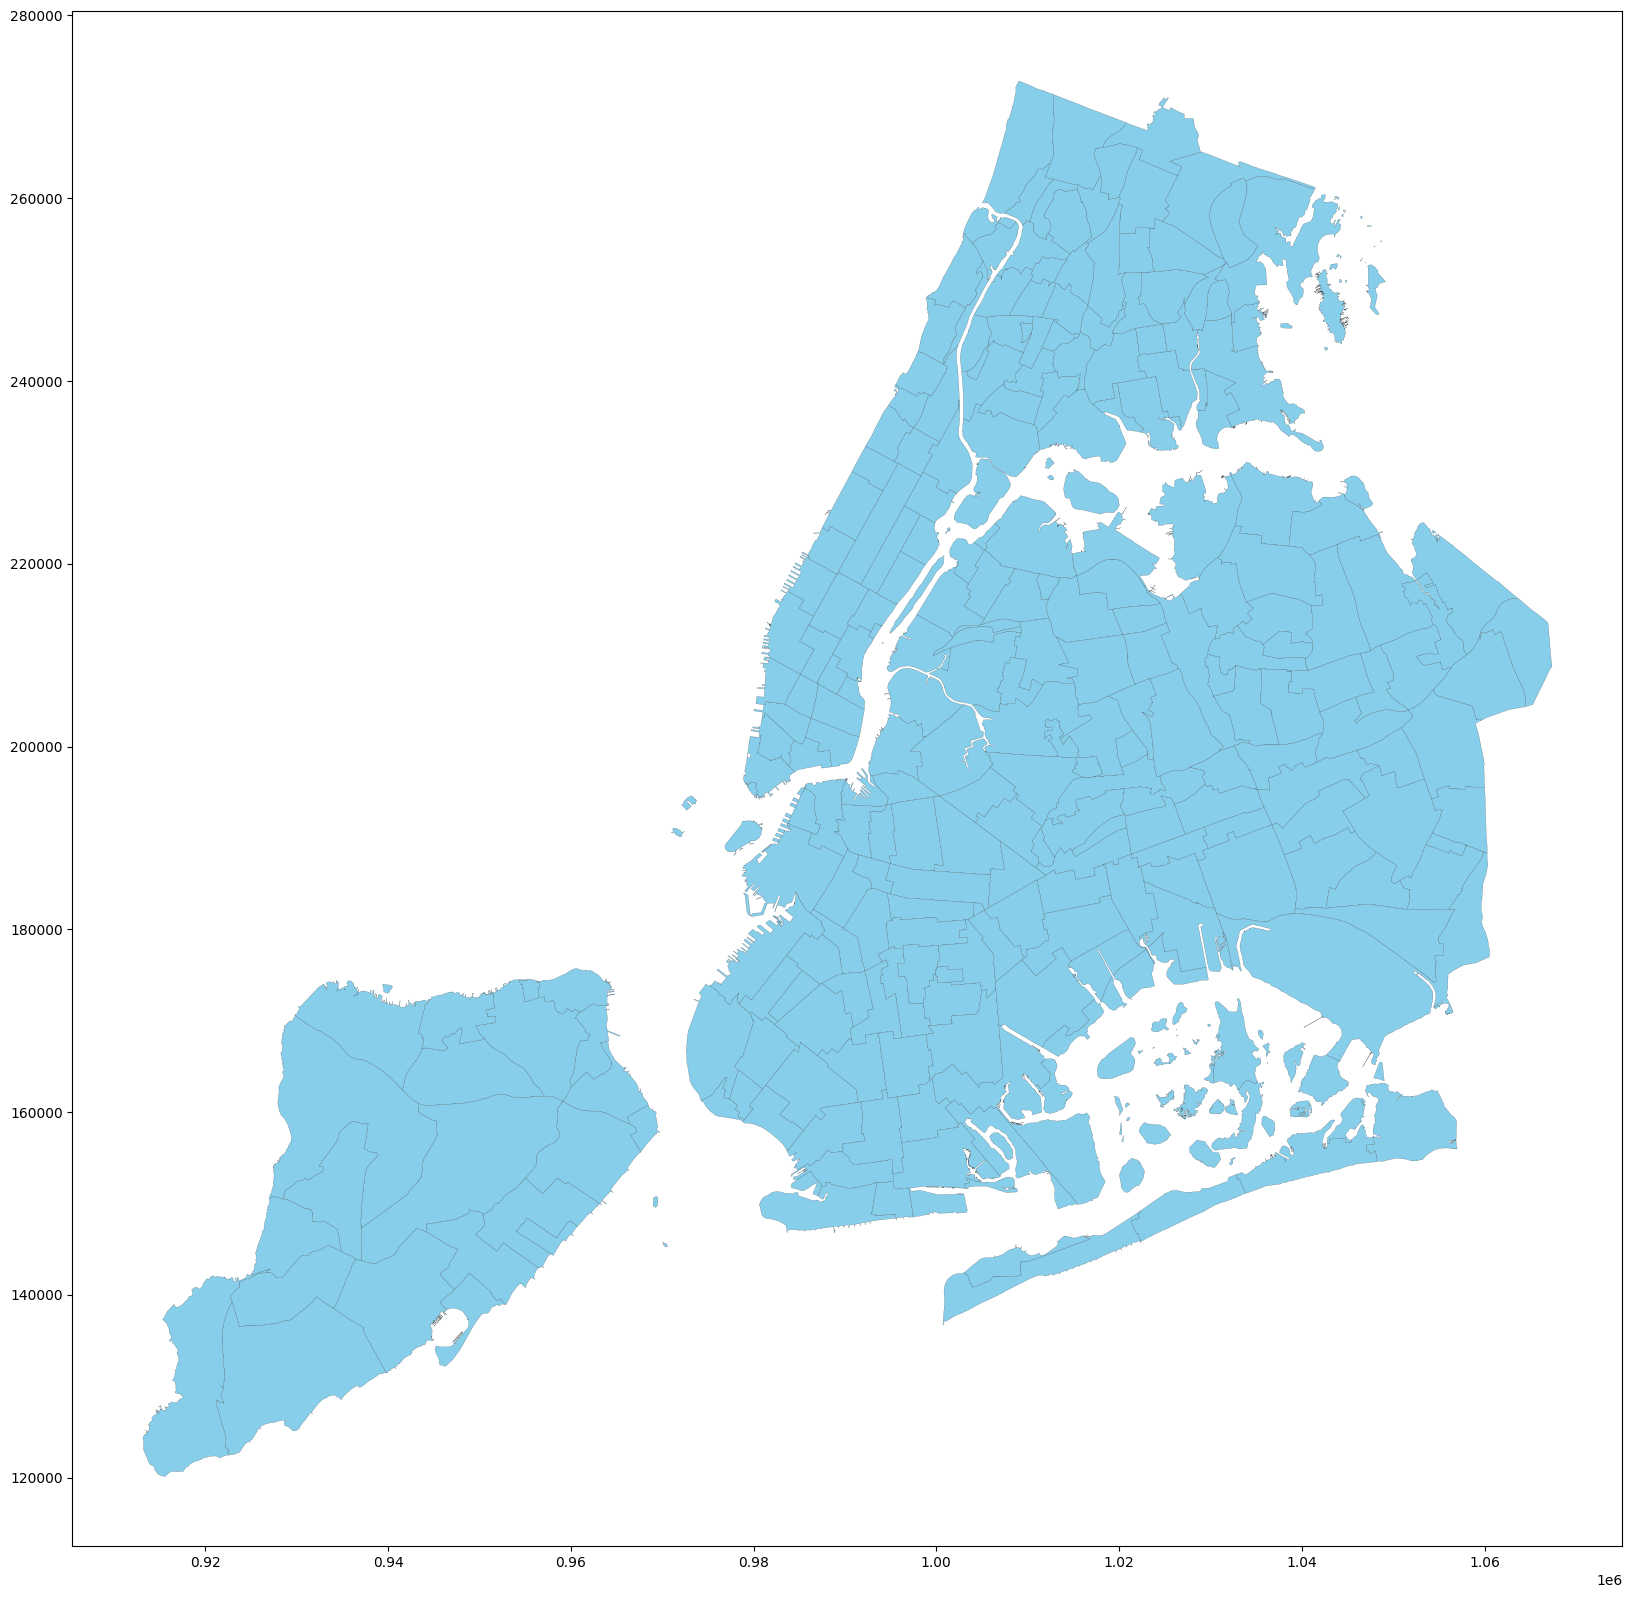

In [57]:
nta_df.plot(
    figsize=(20,20),
    color = 'skyblue',
    edgecolor = 'black',
    linewidth=0.1,
    zorder=0,
    facecolor = 'lightgreen',
)

In [50]:
complaints_2025

,cmplnt_num,cmplnt_fr_dt,cmplnt_fr_tm,cmplnt_to_dt,cmplnt_to_tm,addr_pct_cd,rpt_dt,ky_cd,ofns_desc,pd_cd,...,susp_sex,transit_district,latitude,longitude,lat_lon,patrol_boro,station_name,vic_age_group,vic_race,vic_sex
0,318196597,2025-12-31T00:00:00.000,11:57:00,2025-12-31T00:00:00.000,12:05:00,40,2025-12-31T00:00:00.000,109,GRAND LARCENY,443.0,...,U,NaN,40.817356,-73.909331,"(40.817356, -73.909331)",PATROL BORO BRONX,(null),25-44,AMERICAN INDIAN/ALASKAN NATIVE,M
1,318202640,2025-12-31T00:00:00.000,17:10:00,2025-12-31T00:00:00.000,17:18:00,14,2025-12-31T00:00:00.000,118,DANGEROUS WEAPONS,793.0,...,F,NaN,40.754177,-73.984595,"(40.75417678, -73.98459514)",PATROL BORO MAN SOUTH,(null),UNKNOWN,UNKNOWN,E
2,318170925,2025-12-30T00:00:00.000,23:40:00,2025-12-31T00:00:00.000,00:27:00,101,2025-12-31T00:00:00.000,344,ASSAULT 3 & RELATED OFFENSES,113.0,...,M,NaN,40.599187,-73.750221,"(40.599187, -73.750221)",PATROL BORO QUEENS SOUTH,(null),18-24,BLACK,M
3,318205041,2025-12-23T00:00:00.000,17:56:00,2025-12-23T00:00:00.000,18:04:00,108,2025-12-31T00:00:00.000,341,PETIT LARCENY,321.0,...,M,NaN,40.746705,-73.943472,"(40.746705, -73.943472)",PATROL BORO QUEENS NORTH,(null),UNKNOWN,UNKNOWN,D
4,318204044,2025-12-31T00:00:00.000,19:39:00,2025-12-31T00:00:00.000,19:39:00,103,2025-12-31T00:00:00.000,351,CRIMINAL MISCHIEF & RELATED OF,258.0,...,(null),NaN,40.708380,-73.791676,"(40.70837971, -73.79167576)",PATROL BORO QUEENS SOUTH,(null),UNKNOWN,UNKNOWN,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579556,298733274,2024-12-30T00:00:00.000,09:30:00,2024-12-31T00:00:00.000,14:30:00,48,2025-01-01T00:00:00.000,110,GRAND LARCENY OF MOTOR VEHICLE,441.0,...,(null),NaN,40.838593,-73.876457,"(40.838593, -73.876457)",PATROL BORO BRONX,(null),45-64,BLACK,F
579557,298749236,2025-01-01T00:00:00.000,00:50:00,2025-01-01T00:00:00.000,00:52:00,46,2025-01-01T00:00:00.000,113,FORGERY,725.0,...,M,NaN,40.847816,-73.907531,"(40.847815514765855, -73.90753109698773)",PATROL BORO BRONX,(null),UNKNOWN,UNKNOWN,M
579558,298712914,2025-01-01T00:00:00.000,03:10:00,2025-01-01T00:00:00.000,03:15:00,33,2025-01-01T00:00:00.000,110,GRAND LARCENY OF MOTOR VEHICLE,441.0,...,M,NaN,40.839531,-73.940889,"(40.839531, -73.940889)",PATROL BORO MAN NORTH,(null),45-64,AMERICAN INDIAN/ALASKAN NATIVE,M
579559,298712937,2025-01-01T00:00:00.000,01:22:00,2025-01-01T00:00:00.000,01:25:00,44,2025-01-01T00:00:00.000,118,DANGEROUS WEAPONS,792.0,...,M,NaN,40.844588,-73.904847,"(40.84458830022735, -73.90484654915383)",PATROL BORO BRONX,(null),UNKNOWN,UNKNOWN,E


In [49]:
complaints_2025.duplicated(subset='cmplnt_num').sum()

np.int64(0)

In [5]:
complaints_clean = complaints_2025.dropna(
    subset=["latitude", "longitude"]
).copy()



In [9]:
complaints_gdf = gpd.GeoDataFrame(
    complaints_clean,
    geometry=gpd.points_from_xy(
        complaints_clean["longitude"],
        complaints_clean["latitude"]
    ),
    crs="EPSG:4326"
)



In [13]:
complaints_gdf = complaints_gdf.to_crs(nta_df.crs)


In [14]:
complaints_with_nta = gpd.sjoin(
    complaints_gdf,
    nta_df[["NTA2020", "NTAName", "geometry"]],
    how="inner",
    predicate="within"
)



In [ ]:

complaint_counts = (
    complaints_with_nta
    .groupby("NTA2020")["cmplnt_num"]
    .nunique()
    .reset_index(name="complaint_count")
)



In [16]:
nta_heatmap = nta_df.merge(
    complaint_counts,
    on="NTA2020",
    how="left"
)



In [17]:
# Neighborhoods with no complaints
nta_heatmap["complaint_count"] = (
    nta_heatmap["complaint_count"]
    .fillna(0)
    .astype(int)
)



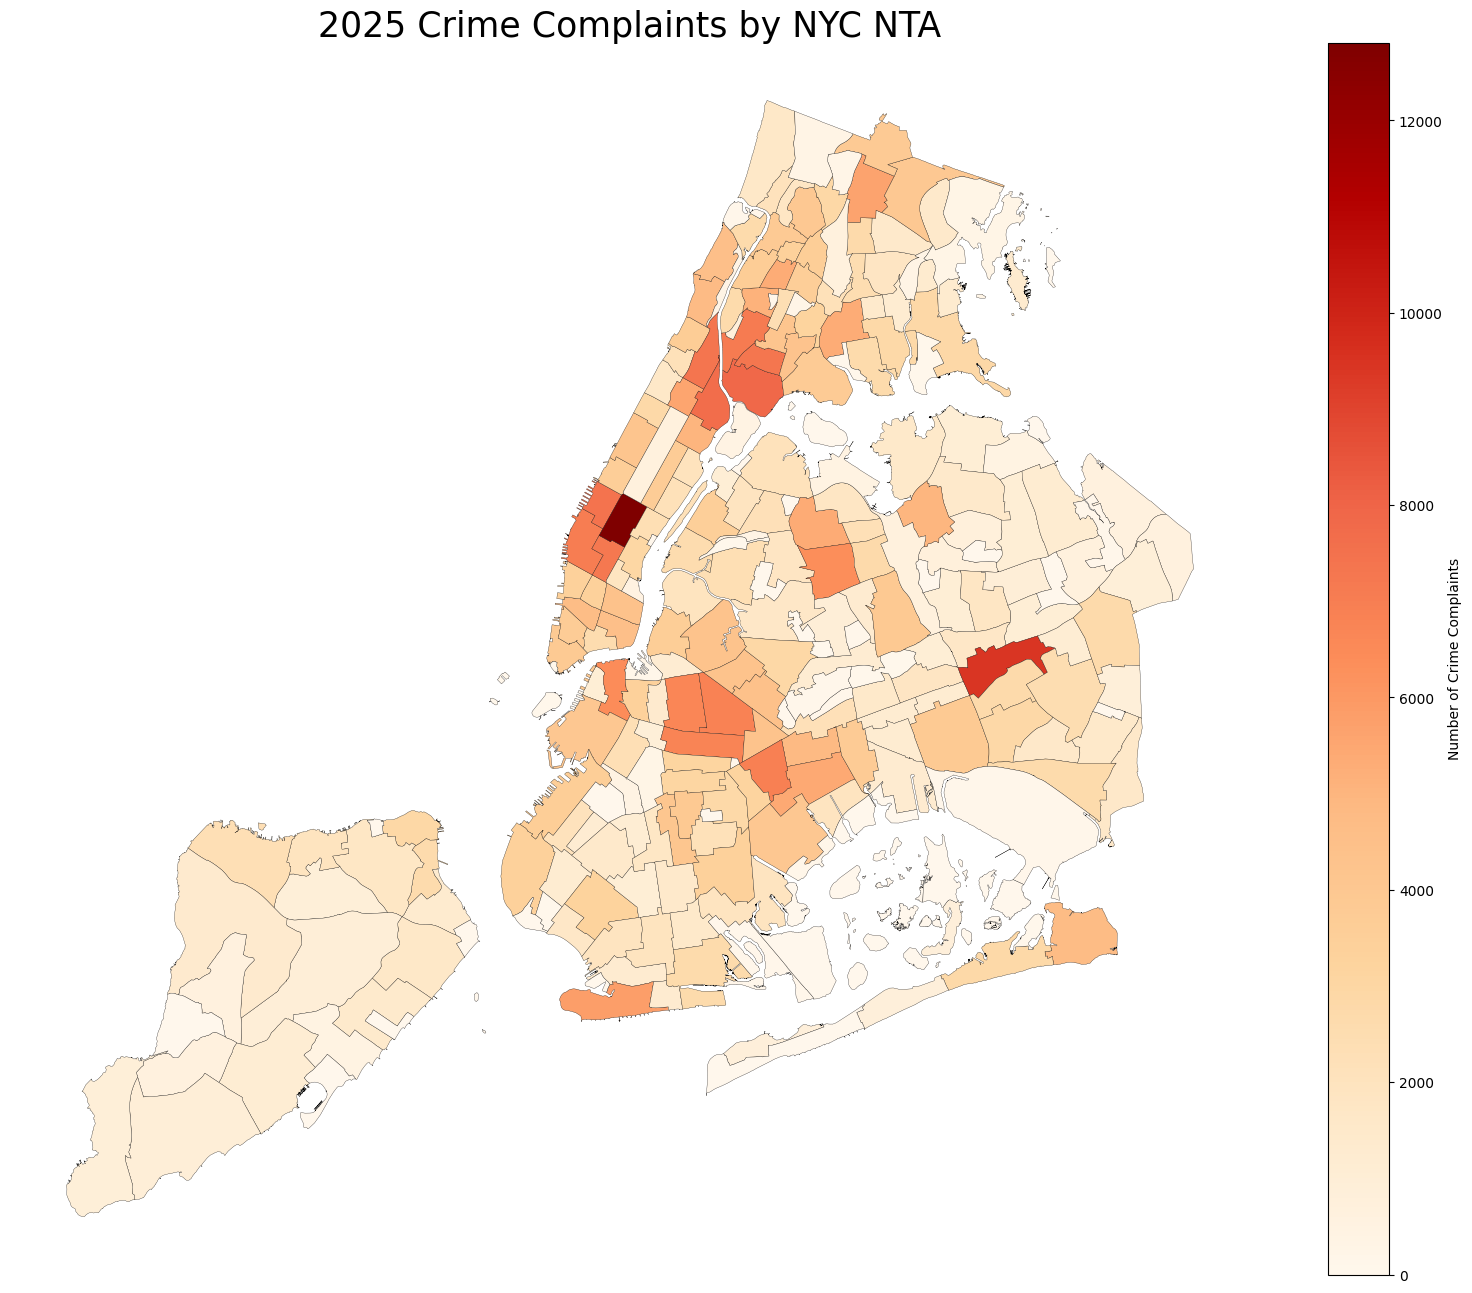

In [28]:
ax = nta_heatmap.plot(
    column="complaint_count",
    figsize=(20, 20),
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    legend_kwds={
        "label": "Number of Crime Complaints",
        "shrink": 0.8
    }
)

ax.set_title("2025 Crime Complaints by NYC NTA", fontsize=25)
ax.axis("off")

plt.show()

In [20]:
nta_heatmap["complaint_count"].max()

np.int64(12810)

### 5. What years had more complaints happens

In [ ]:
# offset = random.randint(0, 2_000_000)

# url = (
#     "https://data.cityofnewyork.us/resource/qgea-i56i.json"
#     f"?$limit=50000&$offset={offset}"
# )

In [ ]:
# complaints = pd.read_json(url)

In [76]:
complaints_2025['rpt_dt'] = pd.to_datetime(complaints_2025['rpt_dt'])

In [87]:
complaints_2025['vic_race'].value_counts()

vic_race
UNKNOWN                           207130
BLACK                             135176
WHITE HISPANIC                     91574
WHITE                              73913
ASIAN / PACIFIC ISLANDER           43080
BLACK HISPANIC                     25730
AMERICAN INDIAN/ALASKAN NATIVE      2774
(null)                               184
Name: count, dtype: int64

In [88]:
cleaned_race = complaints_2025[
    complaints_2025["vic_race"].notna() &
    (complaints_2025["vic_race"] != "UNKNOWN")
]

In [79]:
complaints_2025['year']      = complaints_2025['rpt_dt'].dt.year
complaints_2025['month']     = complaints_2025['rpt_dt'].dt.month
complaints_2025['day']       = complaints_2025['rpt_dt'].dt.day
complaints_2025['hour']      = complaints_2025['rpt_dt'].dt.hour
complaints_2025['dayofweek'] = complaints_2025['rpt_dt'].dt.dayofweek
complaints_2025['day_name']  = complaints_2025['rpt_dt'].dt.day_name()

print("Time attributes: year, month, day, hour, dayofweek, day_name")
print(f"Years: {sorted(complaints_2025['year'].unique())}")

Time attributes: year, month, day, hour, dayofweek, day_name
Years: [np.int32(2025)]


In [81]:
days = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

complaints_2025["day_name"] = pd.Categorical(
    complaints_2025["day_name"],
    categories=days,
    ordered=True
)

complaints_2025.groupby("day_name").size()

day_name
Monday       81326
Tuesday      87290
Wednesday    89869
Thursday     85556
Friday       85697
Saturday     77239
Sunday       72584
dtype: int64

<Axes: title={'center': 'Crime Complaints by Day of Week'}, xlabel='day_name'>

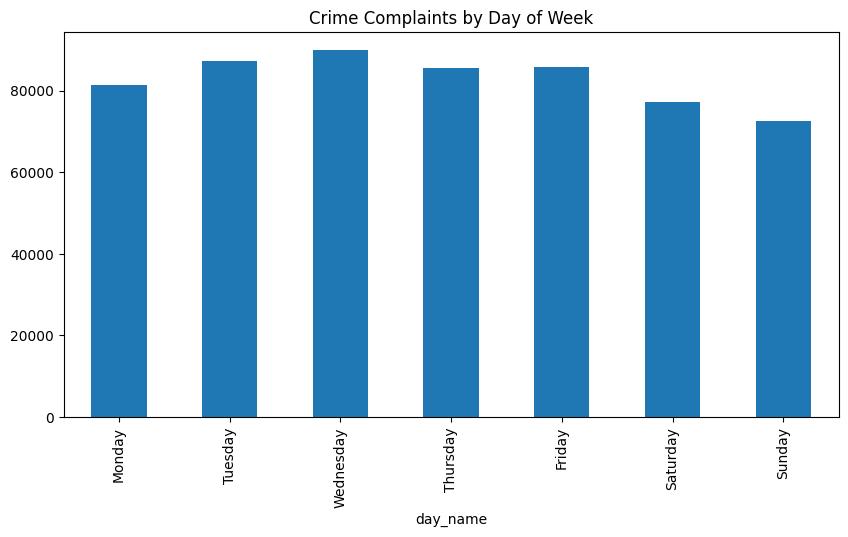

In [83]:
weekday = complaints_2025.groupby("day_name").size()

weekday.plot(
    kind="bar",
    figsize=(10,5),
    title="Crime Complaints by Day of Week"
)

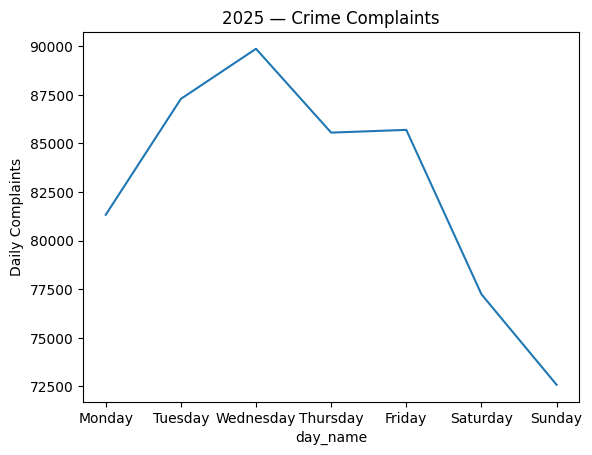

In [85]:
ax = weekday.plot()
ax.set_ylabel('Daily Complaints')
ax.set_title('2025 — Crime Complaints')
plt.show()

In [80]:
complaints_2025

,cmplnt_num,cmplnt_fr_dt,cmplnt_fr_tm,cmplnt_to_dt,cmplnt_to_tm,addr_pct_cd,rpt_dt,ky_cd,ofns_desc,pd_cd,...,station_name,vic_age_group,vic_race,vic_sex,year,month,day,hour,dayofweek,day_name
0,318196597,2025-12-31T00:00:00.000,11:57:00,2025-12-31T00:00:00.000,12:05:00,40,2025-12-31,109,GRAND LARCENY,443.0,...,(null),25-44,AMERICAN INDIAN/ALASKAN NATIVE,M,2025,12,31,0,2,Wednesday
1,318202640,2025-12-31T00:00:00.000,17:10:00,2025-12-31T00:00:00.000,17:18:00,14,2025-12-31,118,DANGEROUS WEAPONS,793.0,...,(null),UNKNOWN,UNKNOWN,E,2025,12,31,0,2,Wednesday
2,318170925,2025-12-30T00:00:00.000,23:40:00,2025-12-31T00:00:00.000,00:27:00,101,2025-12-31,344,ASSAULT 3 & RELATED OFFENSES,113.0,...,(null),18-24,BLACK,M,2025,12,31,0,2,Wednesday
3,318205041,2025-12-23T00:00:00.000,17:56:00,2025-12-23T00:00:00.000,18:04:00,108,2025-12-31,341,PETIT LARCENY,321.0,...,(null),UNKNOWN,UNKNOWN,D,2025,12,31,0,2,Wednesday
4,318204044,2025-12-31T00:00:00.000,19:39:00,2025-12-31T00:00:00.000,19:39:00,103,2025-12-31,351,CRIMINAL MISCHIEF & RELATED OF,258.0,...,(null),UNKNOWN,UNKNOWN,E,2025,12,31,0,2,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579556,298733274,2024-12-30T00:00:00.000,09:30:00,2024-12-31T00:00:00.000,14:30:00,48,2025-01-01,110,GRAND LARCENY OF MOTOR VEHICLE,441.0,...,(null),45-64,BLACK,F,2025,1,1,0,2,Wednesday
579557,298749236,2025-01-01T00:00:00.000,00:50:00,2025-01-01T00:00:00.000,00:52:00,46,2025-01-01,113,FORGERY,725.0,...,(null),UNKNOWN,UNKNOWN,M,2025,1,1,0,2,Wednesday
579558,298712914,2025-01-01T00:00:00.000,03:10:00,2025-01-01T00:00:00.000,03:15:00,33,2025-01-01,110,GRAND LARCENY OF MOTOR VEHICLE,441.0,...,(null),45-64,AMERICAN INDIAN/ALASKAN NATIVE,M,2025,1,1,0,2,Wednesday
579559,298712937,2025-01-01T00:00:00.000,01:22:00,2025-01-01T00:00:00.000,01:25:00,44,2025-01-01,118,DANGEROUS WEAPONS,792.0,...,(null),UNKNOWN,UNKNOWN,E,2025,1,1,0,2,Wednesday


In [77]:
complaints_2025.groupby(complaints_2025["rpt_dt"].dt.year).size()

rpt_dt
2025    579561
dtype: int64

In [78]:
complaints_2025.groupby(complaints_2025['rpt_dt'].dt.month).size()

rpt_dt
1     46759
2     42522
3     49449
4     49475
5     51220
6     49192
7     50690
8     49776
9     49957
10    49911
11    46776
12    43834
dtype: int64

In [114]:
complaints_2025 = complaints_2025.dropna(subset=["vic_race"])

In [75]:
# complaints['rpt_dt'].hist(bins=48,figsize=(20,10), density=True,alpha=0.5, color='red')


In [117]:
cleaned_race = complaints_2025[
    complaints_2025["vic_race"] != "(null)"
]

In [118]:
monthly_race = (
    cleaned_race
    .groupby(["month", "vic_race"])
    .size()
    .unstack(fill_value=0)
)

In [119]:
print(monthly_race.columns)

Index(['AMERICAN INDIAN/ALASKAN NATIVE', 'ASIAN / PACIFIC ISLANDER', 'BLACK',
       'BLACK HISPANIC', 'UNKNOWN', 'WHITE', 'WHITE HISPANIC'],
      dtype='str', name='vic_race')


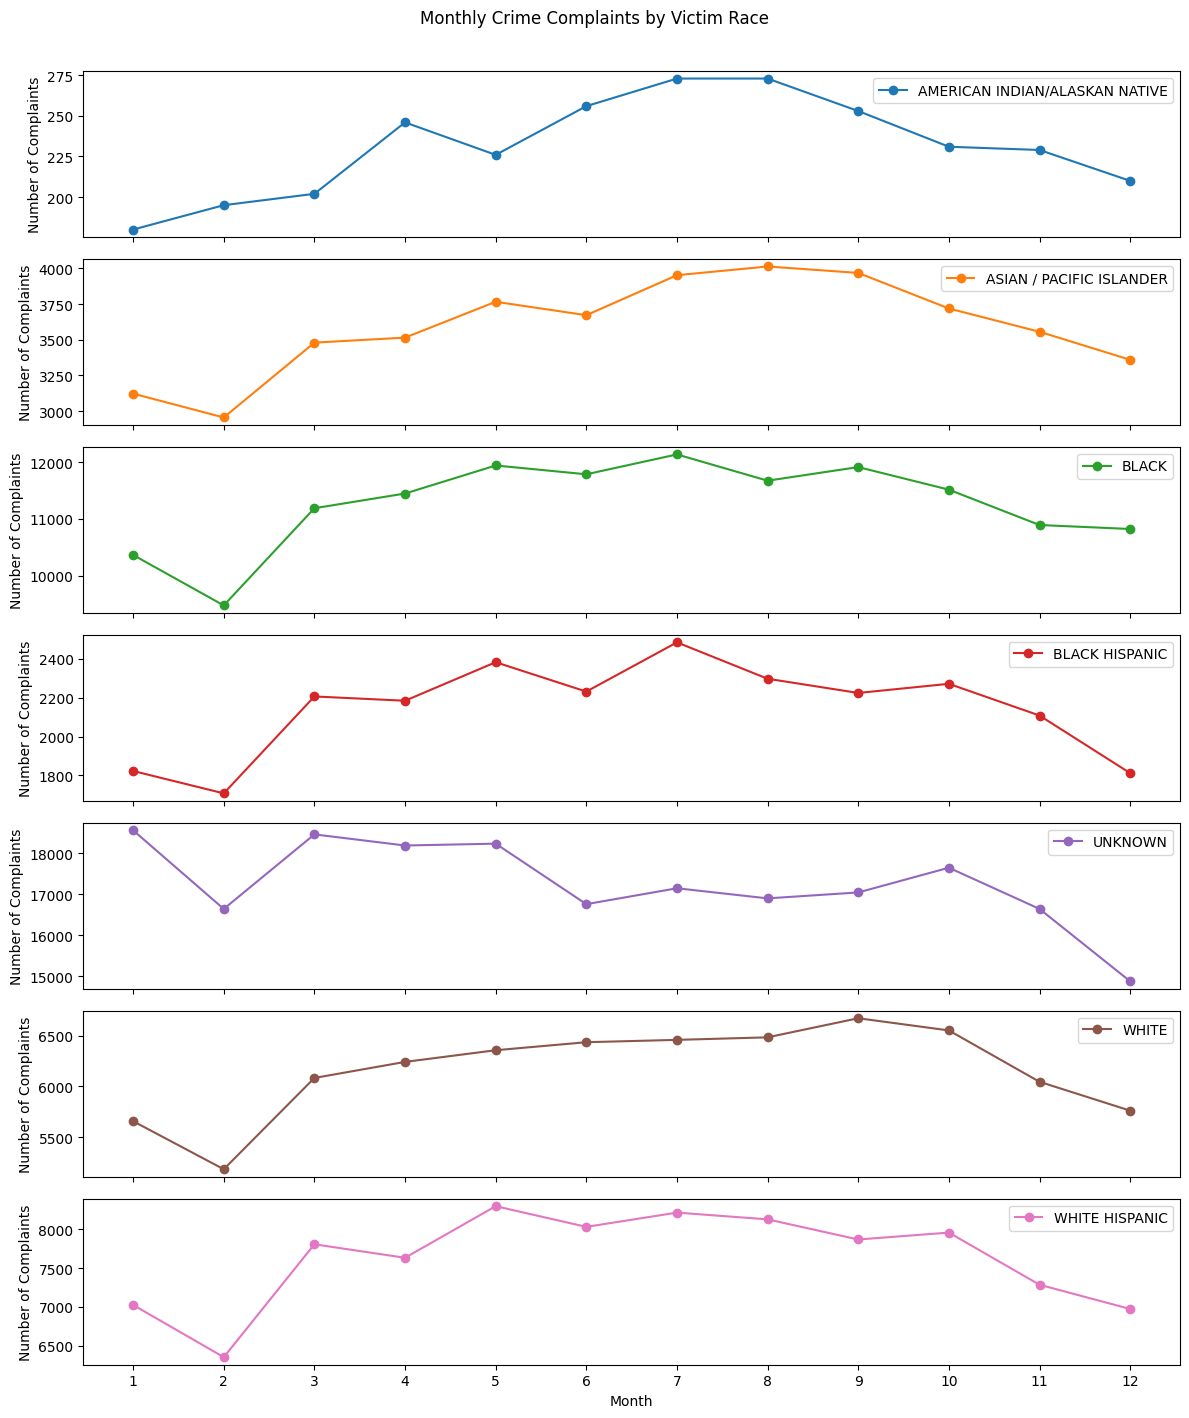

In [120]:
axes = monthly_race.plot(
    kind="line",
    marker="o",
    figsize=(12, 14),
    subplots=True,
    sharex=True,
    legend=True
)

for ax in axes:
    ax.set_ylabel("Number of Complaints")
    ax.set_xticks(range(1, 13))
    ax.set_xlabel("Month")

plt.suptitle("Monthly Crime Complaints by Victim Race", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
df_wide = complaints_2025.set_index('rpt_dt').select_dtypes(include=[np.number])


In [100]:
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

complaints_2025["season"] = complaints_2025["month"].map(season_map)

In [101]:
complaints_2025["day_type"] = complaints_2025["dayofweek"].map(
    lambda x: "Weekend" if x >= 5 else "Workday"
)

In [106]:
complaints_2025["hour"] = pd.to_numeric(
    complaints_2025["cmplnt_fr_tm"].str.split(":").str[0],
    errors="coerce"
)

In [107]:
complaints_2025["hour"].value_counts().sort_index()

hour
0     25646
1     17784
2     15090
3     12898
4     11089
5      8558
6      9199
7     14097
8     20887
9     21791
10    23896
11    25357
12    31083
13    28085
14    31854
15    34936
16    35228
17    34999
18    34844
19    33533
20    31724
21    28509
22    25959
23    22515
Name: count, dtype: int64

In [109]:
complaints_2025["season"]
complaints_2025["day_type"]
complaints_2025["hour"]

0         11
1         17
2         23
3         17
4         19
          ..
579556     9
579557     0
579558     3
579559     1
579560    14
Name: hour, Length: 579561, dtype: int64

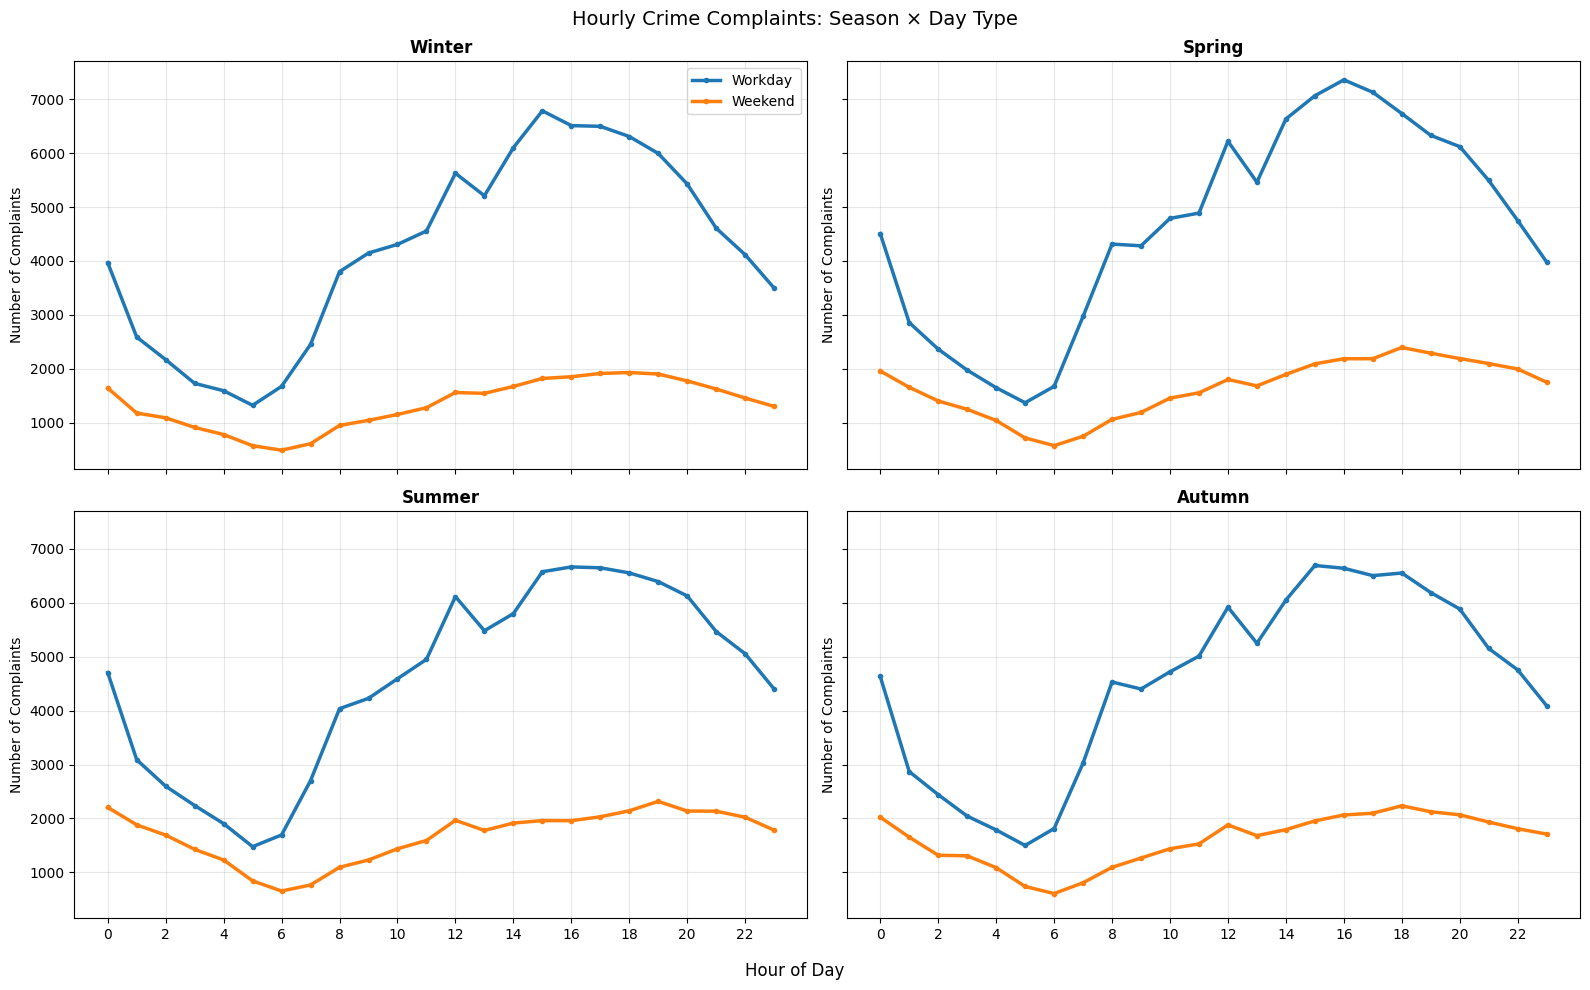

In [111]:
seasons = ["Winter", "Spring", "Summer", "Autumn"]

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    sharex=True,
    sharey=True
)

for idx, season in enumerate(seasons):

    ax = axes[idx // 2, idx % 2]

    for day_type in ["Workday", "Weekend"]:

        hourly_counts = (
            complaints_2025[
                (complaints_2025["season"] == season) &
                (complaints_2025["day_type"] == day_type)
            ]
            .groupby("hour")
            .size()
            .reindex(range(24), fill_value=0)
        )

        ax.plot(
            hourly_counts.index,
            hourly_counts.values,
            marker="o",
            linewidth=2.5,
            markersize=3,
            label=day_type
        )

    ax.set_title(season, fontweight="bold")
    ax.set_ylabel("Number of Complaints")
    ax.set_xticks(range(0, 24, 2))
    ax.grid(alpha=0.3)

    if idx == 0:
        ax.legend()

fig.suptitle(
    "Hourly Crime Complaints: Season × Day Type",
    fontsize=14
)

fig.supxlabel("Hour of Day")

plt.tight_layout()
plt.show()

In [105]:
complaints_2025["cmplnt_fr_tm"].head()

0    11:57:00
1    17:10:00
2    23:40:00
3    17:56:00
4    19:39:00
Name: cmplnt_fr_tm, dtype: str